In [3]:
import pandas as pd 
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### DATA Inspection and understanding
df.shape
df.info()
df.describe()
df.dtypes
df.isnull().sum()
To overview tha complete dataset by running these commands

In [4]:
df.shape

(8807, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [8]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [9]:
df.isnull().sum()  ## to check the missing values

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### Handling Missing values
here we use the fillna because a huge amount of missing values are present in director , cast and country column because if we use dropna the huge amount of data wasted

In [10]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')


### Dropna
we apply dropna on [rating ,duration , date_added] because a tiny amount of data is missing and  by dropping these column it can't affect the whole datset and efficiency of model.

In [11]:
df = df.dropna(subset = ['rating' , 'duration' , 'date_added'])

In [12]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [13]:
df.duplicated().sum()   ## checking the duplicates value in datset

np.int64(0)

In [14]:
df['type'].unique() ## to check the ditinct values in any column if present 


array(['Movie', 'TV Show'], dtype=object)

In [16]:

df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [17]:

df['country'].nunique()

749

## str.strip()
it is used to remove the extra spaces from  the biginning and the end of the text value.it does not remove the spaces in middle , only from both sides.
why we  have to remove the extra spaces and how it is necessary?
Sometimes during data entry an extra spaces get added by mistake. You can't see it with the eyes, but for python it becomes two different value.


In [20]:
before = df['country'].nunique()
df['country'] = df['country'].str.strip() 
after = df['country'].nunique()

print(before, after)

749 749


In [18]:
before = df['type'].nunique()
df['type']= df['type'].str.strip()
after = df['type'].nunique()
print(before, after)

2 2


In [19]:
before = df['rating'].nunique()
df['rating'] = df['rating'].str.strip()
after = df['rating'].nunique()

print(before, after)

14 14


In [20]:
df['date_added'].head() ## to check the date format

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
Name: date_added, dtype: object

### Why is it necessary to covert to datetime?
When a data is in the form of text/string(04-jan-2022 or September 24 ,2021) , Python treats  it as just combination of letters and number— exactly like a normal sentence. With this you. cannot do the following:

- *Extract just year/month/day* (`.dt.year`, `.dt.month`)
- *Find the difference between two dates* (how many days have passed)
- *Sort dates correctly* (text is sorted alphabetically, so `"2 January"` will come after `"10 January"` in text, which is wrong)
- *Filter rows for a specific date range*

When we convert using `pd.to_datetime()`, Python treats it as a special datetime object.

 

In [21]:
df['date_added'] = pd.to_datetime(df['date_added'] , format = 'mixed' , dayfirst = True)

In [22]:
df['date_added'].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]

In [23]:
df['year_added'] = df['date_added'].dt.year  ## to extract further data from date
df['month_added'] = df['date_added'].dt.month

In [24]:
df[['date_added', 'year_added', 'month_added']].head()

,date_added,year_added,month_added
0,2021-09-25,2021,9
1,2021-09-24,2021,9
2,2021-09-24,2021,9
3,2021-09-24,2021,9
4,2021-09-24,2021,9


In [25]:
movies = df[df['type'] == 'Movie'].copy()
tv_shows = df[df['type'] == 'TV Show'].copy()

In [26]:
print(movies.shape)
print(tv_shows.shape)

(6126, 14)
(2664, 14)


In [27]:
movies['duration'] = movies['duration'].str.replace(' min', '', regex=False).astype(float)

### .str.replace(' min', '', regex=False) → finds the text " min" (space + min) and replaces it with an empty string (''), effectively removing it
"90 min" → .replace(' min', '') → "90"
### regex=False → tells Python ' min' is not a pattern, just literal text to match exactly (no regex needed since there's no special symbol like $ or ,)
### .astype(float) → converts the remaining number ("90") into an actual float (90.0)

In [28]:
tv_shows['duration'] = tv_shows['duration'].str.replace(' Seasons', '', regex=False).str.replace(' Season', '', regex=False).astype(float)


## Why two .replace() calls — this matters:

### TV Shows have two different ways duration is written:

If 2 or more seasons → "2 Seasons" (plural, with "s")
If only 1 season → "1 Season" (singular, no "s")

## So it had to be replaced twice:

### First .replace(' Seasons', '') → removes any "Seasons" (plural)
"2 Seasons" → "2"
"1 Season" → stays unchanged for now (since "Seasons" doesn't match, only "Season" without the "s" is there)
### Then .replace(' Season', '') → removes the remaining "Season" (singular)
"1 Season" → "1"

## Chaining (.str.replace().str.replace()) means: 
### the first replace runs across the whole column, its result is passed to the next replace, and they run one after another — this covers both cases (singular and plural).

### What would happen with only one .replace(' Seasons', ''): the "1 Season" rows would still have "Season" left in them (since "Seasons" wouldn't match), and then astype(float) would fail with an error.

In [29]:
print(movies['duration'].head())
print(tv_shows['duration'].head())

0      90.0
6      91.0
7     125.0
9     104.0
12    127.0
Name: duration, dtype: float64
1    2.0
2    1.0
3    1.0
4    2.0
5    1.0
Name: duration, dtype: float64


## Handling Outliers
### Why IQR was used to detect outliers:

###  movies['duration'] is a genuine continuous measurement (minutes) — unlike columns like Id or release_year, which are just labels or categories, duration represents an actual real-world quantity that can meaningfully be "too high" or "too low."

## IQR was chosen over Z-score because:

### IQR works well on skewed data (data that isn't a symmetric bell-curve)
### Z-score works best on normally distributed data — but movie durations tend to lean toward shorter/average lengths with a long tail of longer films, so the distribution is skewed, not symmetric
### IQR is based on median and quartiles, which aren't distorted by extreme values the way mean and standard deviation are — so it gives a more reliable boundary for detecting outliers in skewed data

## The IQR formula:

Q1 = 25th percentile
Q3 = 75th percentile
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

### Any value outside these bounds was flagged as an outlier — this returned 449 outliers.

### Why Log Transform was used to handle those outliers (instead of removing or capping):

## Before deciding, the key question was: are these outliers genuine or corrupted data?

### Very short movies (e.g., 3–20 min) are likely legitimate short films or documentaries
### Very long movies (e.g., 200+ min) are likely legitimate epics or special editions

### None of this looked like data-entry errors — these are real, valid values, just less common.

Given that:

### Removing them would throw away real data unnecessarily
### Capping them would artificially flatten legitimate long/short films to the same boundary value, hiding real differences
### Log Transform compresses the scale without deleting or distorting any data point — it just reduces the extreme values' disproportionate influence

### The histogram confirmed this decision was right: before the transform, the distribution was heavily right-skewed (most values bunched on the left with a long tail). After np.log1p(), the distribution became roughly symmetric/bell-shaped — which is also better for any machine learning model trained on this data later, since most models perform better with normally distributed features.

In [30]:
Q1 = movies['duration'].quantile(0.25)
Q3 = movies['duration'].quantile(0.75)
IQR = Q3-Q1 
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
outliers = movies[(movies['duration']<lower_bound) | (movies['duration'] > upper_bound)]
print(outliers.shape[0])

449


## BoxPlot
### to visualize the outliers

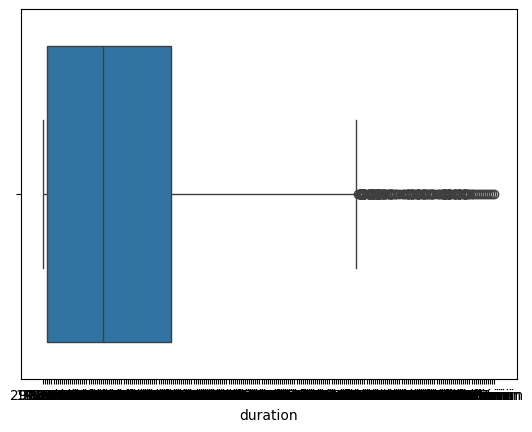

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x = df['duration'])
plt.show()

## Histogram
### to visualize outliers through bargraph

<Axes: >

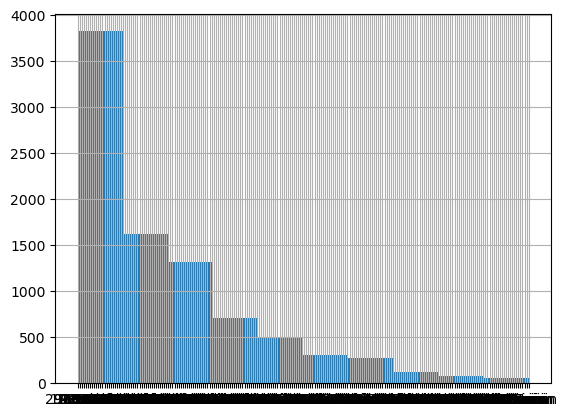

In [32]:
df['duration'].hist()

In [35]:
import numpy as np 
movies['duration'] = np.log1p(movies['duration'])
                          

## Histogram after log transform

<Axes: >

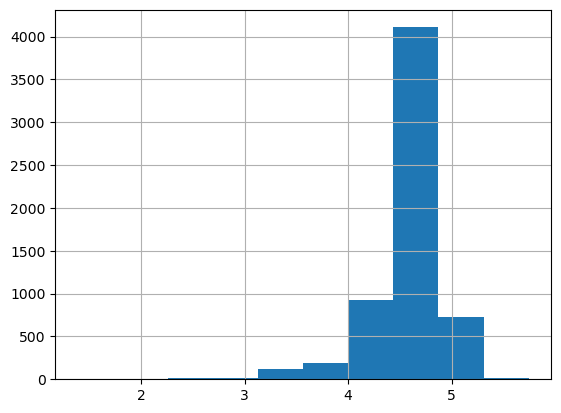

In [36]:
df['duration'].hist()